<a href="https://colab.research.google.com/github/ChiriKamau/soma/blob/main/notebooks/soma_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# school attendanc data

In [20]:
# Go to /content to avoid path issues
%cd /content
!rm -rf soma
!git clone https://github.com/ChiriKamau/soma.git
%cd soma


/content
Cloning into 'soma'...
remote: Enumerating objects: 325, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 325 (delta 15), reused 22 (delta 9), pack-reused 295 (from 1)
Receiving objects: 100% (325/325), 16.13 MiB | 22.29 MiB/s, done.
Resolving deltas: 100% (159/159), done.
/content/soma


In [21]:
import sys
sys.path.insert(0, '/content/soma')  # parent folder of fynesse


In [22]:
import importlib
import fynesse.access, fynesse.assess, fynesse.address

importlib.reload(fynesse.access)
importlib.reload(fynesse.assess)
importlib.reload(fynesse.address)


<module 'fynesse.address' from '/content/soma/fynesse/address.py'>

In [23]:
from fynesse.access import attendance_acs, population_acs, education_acs, schools_acs, secondary_acs, univ_tvet_acs
from fynesse.assess import attendance_ass, population_ass, education_ass, schools_ass, secondary_ass, univ_tvet_ass
from fynesse.address import attendance_add, population_add, population_vs_attendance, education_add, schools_add, secondary_add, univ_tvet_add


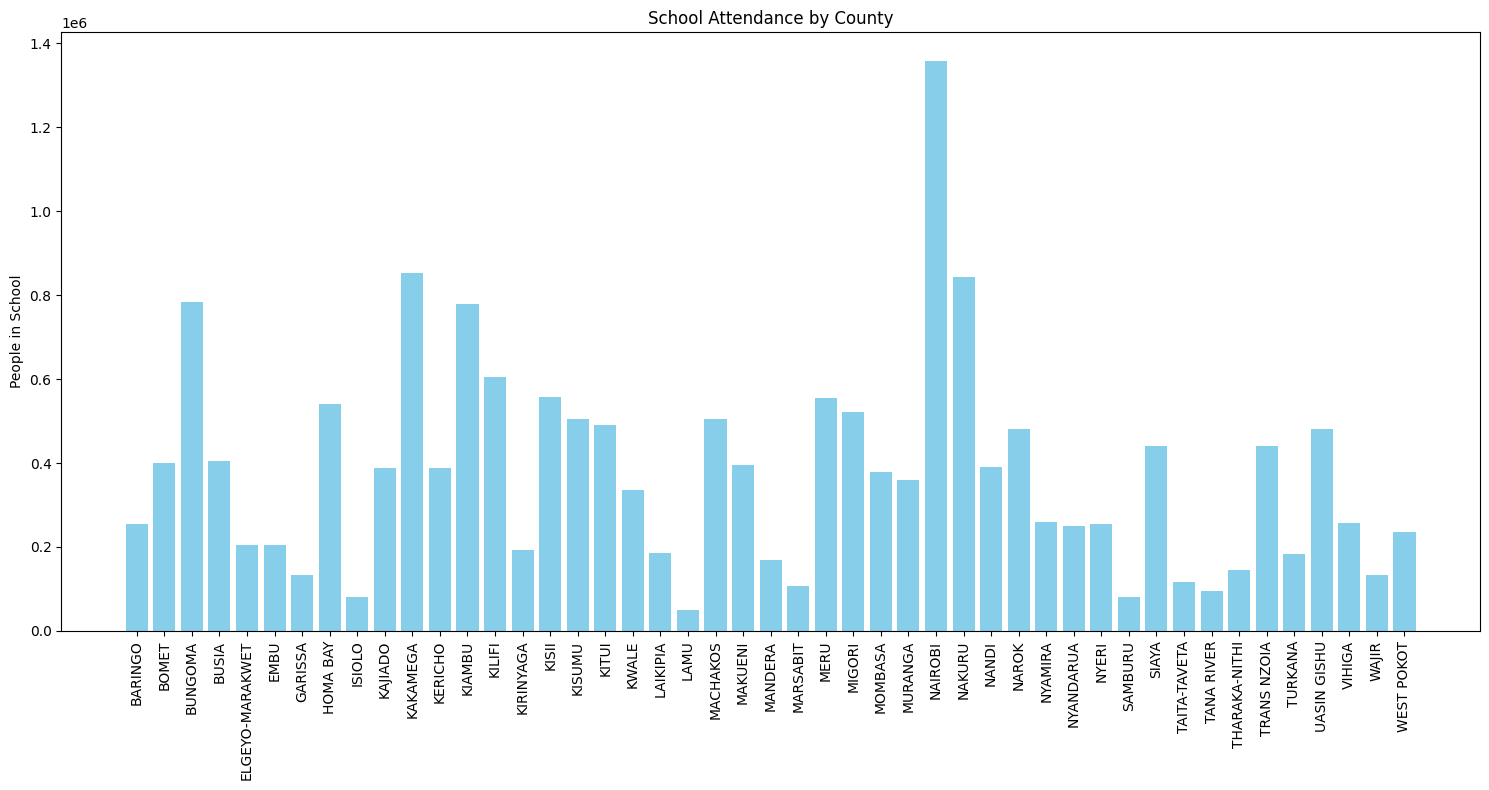

In [24]:

# Usage
url = "https://raw.githubusercontent.com/ChiriKamau/soma/main/data/distribution-of-population-age-3-years-and-above-by-school-attendance-status-area-of-residence-s.csv"

df_raw = attendance_acs(url)
county_data, area_col, school_col = attendance_ass(df_raw)
attendance_add(county_data, area_col, school_col)


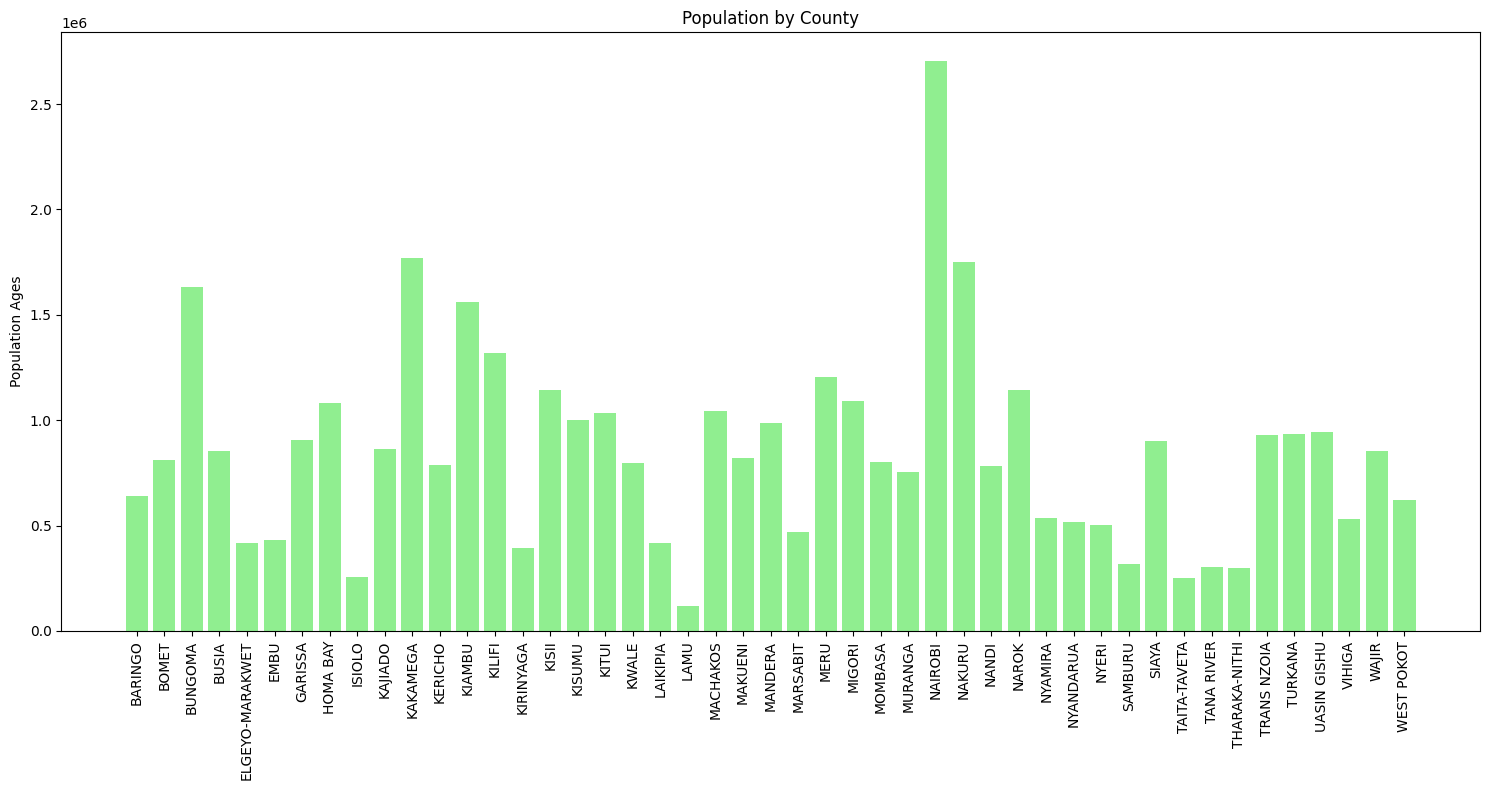

In [25]:

url_pop = "https://raw.githubusercontent.com/ChiriKamau/soma/main/data/Population_scounty_age_gender.csv"
df_pop = population_acs(url_pop)

# Assess with custom age range
county_pop = population_ass(df_pop, min_age=4, max_age=20)


population_add(county_pop)

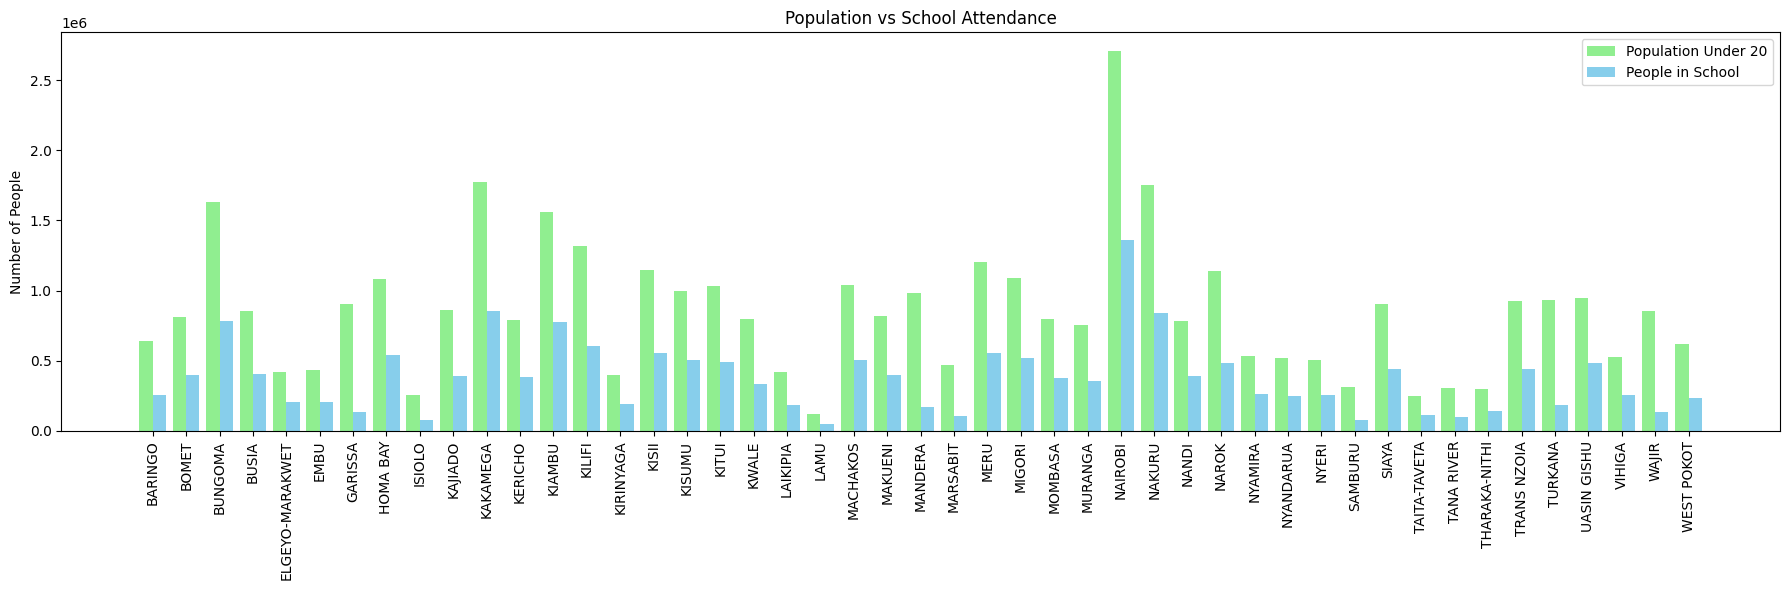

In [26]:
population_vs_attendance(county_pop, county_data)


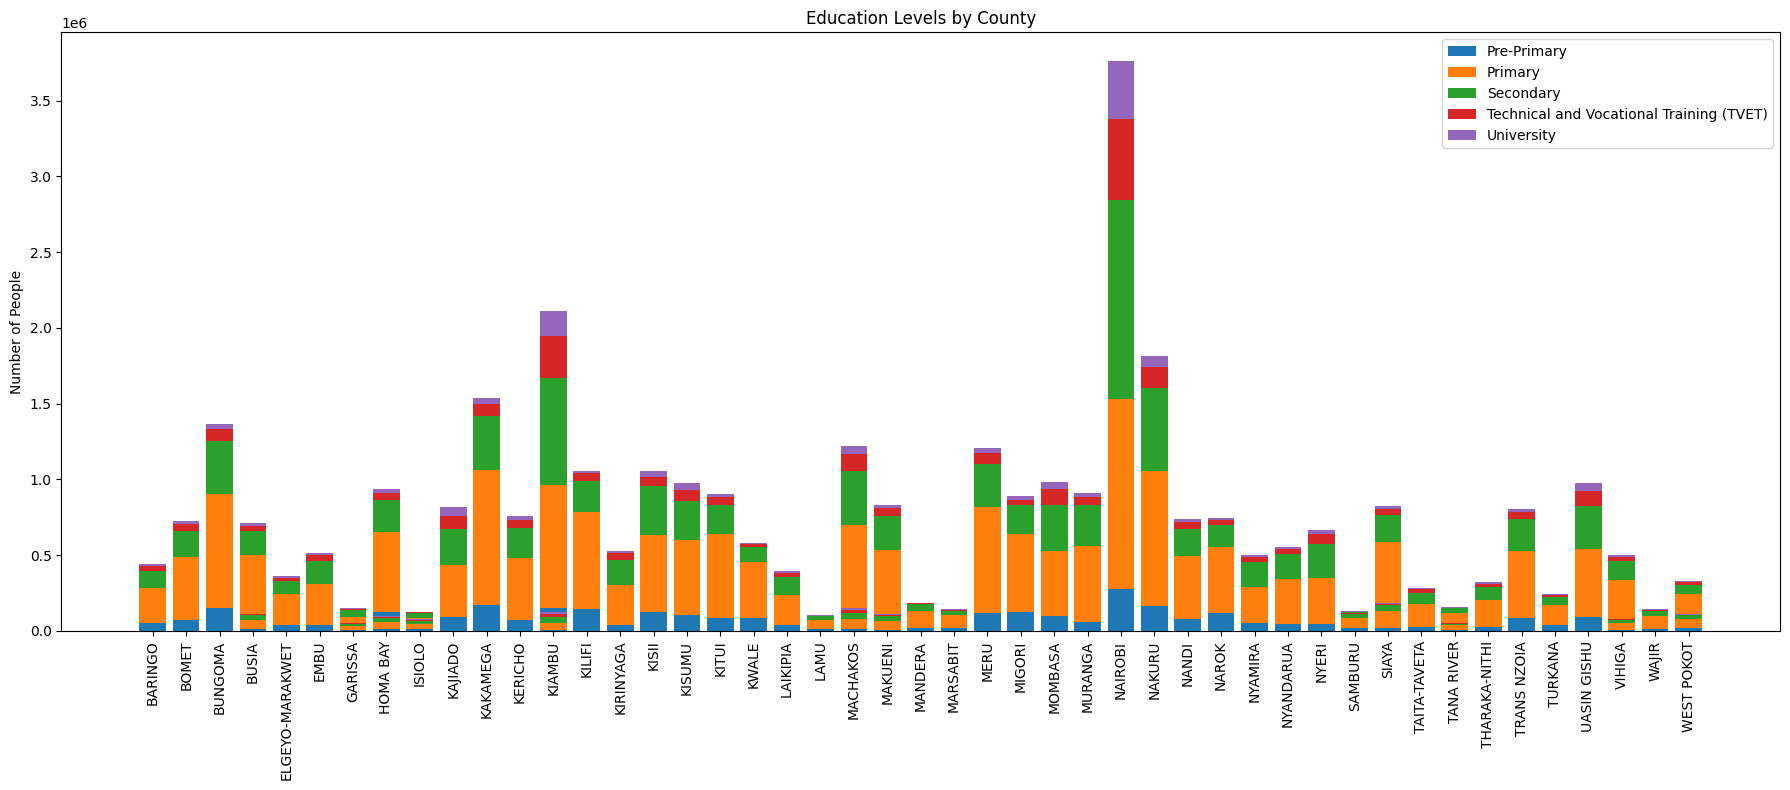

In [27]:

url_edu = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/distribution-of-population-age-3-years-and-above-by-highest-level-of-education-reached-2019-cens.csv"
df_edu = education_acs(url_edu)

county_edu = education_ass(df_edu)  # no need to pass counties_list

education_add(county_edu)


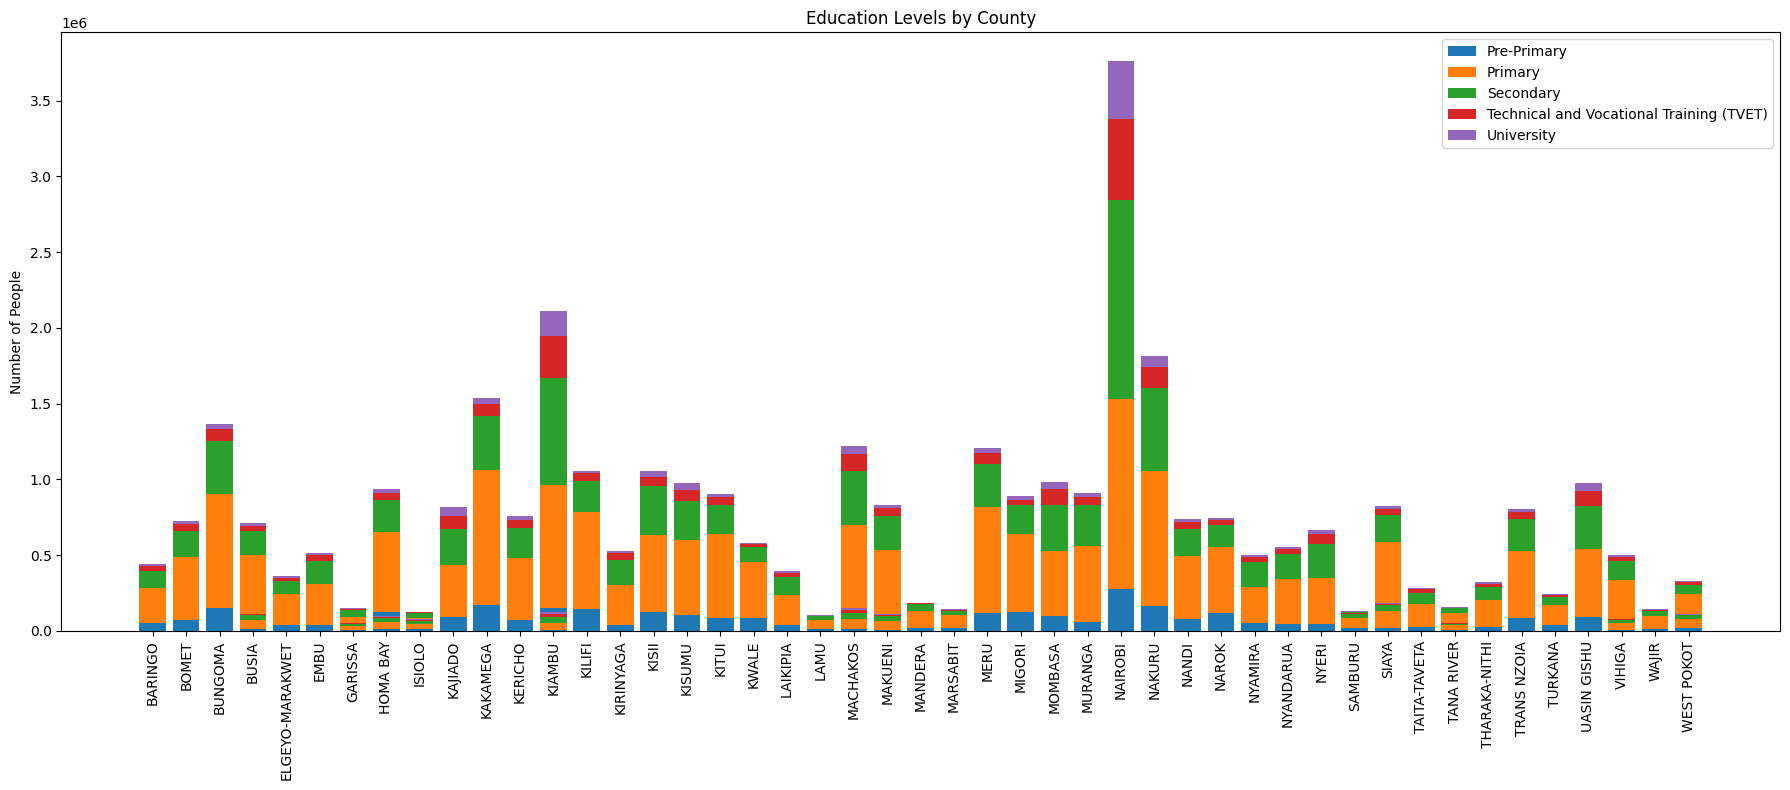

In [29]:
url_schools = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/No_primary_school.csv"
df_schools = schools_acs(url_schools)

county_edu = education_ass(df_edu)
education_add(county_edu)


In [30]:

url_high_schools = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/high_schools_data.csv"
url_secondary = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/No_Secondary_schools.csv"

df_high, df_secondary = secondary_acs(url_high_schools, url_secondary)
county_secondary = secondary_ass(df_high, df_secondary)
secondary_add(county_secondary)


NameError: name 'counties_list' is not defined

In [ ]:
# Load
df_univ, df_tvet = univ_tvet_acs(
    "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/list_of_university.csv",
    "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/TVET_Institutions_Clean.csv"
)

# Count per county
univ_counts, tvet_counts = univ_tvet_ass(df_univ, df_tvet, counties_list)

# Plot combined
univ_tvet_add(univ_counts, tvet_counts)